In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
%matplotlib inline

In [6]:
df = pd.read_csv(r"E:\MADE BY ME\Data Sc\datasets\switch_2\switch_2.csv")

In [7]:
df.shape

(15000, 25)

In [8]:
df.head()

,content_id,source,title,content,date,url,topics,entities,sentiment_class,social_impressions,no_of_comments,no_of_shares,no_of_views,no_of_likes,user_source_id,user_name,user_screen_name,bio,no_of_followers,city,region,country,latitude,longitude,language
0,CID_000000,X,Nintendo Switch 2,console leak,2024-01-01 00:00:00,https://example.com/post/0,Nintendo consoles,Nintendo,negative,564063,75,204,818930,153681,3.958036e+12,user_3916,screen_1202,Nintendo fan,414718.0,New York,NaN,VN,31.978728,-165.333394,vi
1,CID_000001,Threads,NaN,price speculation,2024-01-01 01:00:00,https://example.com/post/1,NaN,Nintendo,negative,397589,453,159,802079,157476,7.913266e+12,user_4575,screen_2022,Nintendo fan,443678.0,NaN,NaN,NaN,55.016868,8.637074,ja
2,CID_000002,TikTok,Switch 2 Leak,game lineup,2024-01-01 02:00:00,https://example.com/post/2,NaN,NaN,neutral,133666,397,71,198375,156686,3.951445e+12,user_2223,screen_4085,NaN,299389.0,NaN,NaN,BR,-10.271194,4.415680,pt
3,CID_000003,X,Switch 2 Rumors,game lineup,2024-01-01 03:00:00,https://example.com/post/3,Nintendo consoles,NaN,positive,253033,85,61,853778,120636,4.791270e+12,user_4675,screen_2981,tech blogger,412101.0,Tokyo,Kanto,JP,37.727396,147.829497,vi
4,CID_000004,Reddit,Nintendo Switch 2,performance discussion,2024-01-01 04:00:00,https://example.com/post/4,handheld video games,Nintendo,positive,459176,478,291,955885,55607,4.924625e+12,user_4143,screen_2464,NaN,464448.0,NaN,NaN,JP,61.622878,86.789507,en


In [9]:
df.columns

Index(['content_id', 'source', 'title', 'content', 'date', 'url', 'topics',
       'entities', 'sentiment_class', 'social_impressions', 'no_of_comments',
       'no_of_shares', 'no_of_views', 'no_of_likes', 'user_source_id',
       'user_name', 'user_screen_name', 'bio', 'no_of_followers', 'city',
       'region', 'country', 'latitude', 'longitude', 'language'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   content_id          15000 non-null  object 
 1   source              15000 non-null  object 
 2   title               9053 non-null   object 
 3   content             15000 non-null  object 
 4   date                15000 non-null  object 
 5   url                 15000 non-null  object 
 6   topics              9031 non-null   object 
 7   entities            8956 non-null   object 
 8   sentiment_class     15000 non-null  object 
 9   social_impressions  15000 non-null  int64  
 10  no_of_comments      15000 non-null  int64  
 11  no_of_shares        15000 non-null  int64  
 12  no_of_views         15000 non-null  int64  
 13  no_of_likes         15000 non-null  int64  
 14  user_source_id      14991 non-null  float64
 15  user_name           15000 non-null  object 
 16  user

In [11]:
df.isnull().sum()

content_id               0
source                   0
title                 5947
content                  0
date                     0
url                      0
topics                5969
entities              6044
sentiment_class          0
social_impressions       0
no_of_comments           0
no_of_shares             0
no_of_views              0
no_of_likes              0
user_source_id           9
user_name                0
user_screen_name         0
bio                   5977
no_of_followers         20
city                  6724
region                7364
country               5331
latitude                22
longitude               30
language                 0
dtype: int64

# Handling Missing Values

In [12]:
# droping columns as it has Extremely High Missing values - ['city','region', 'country', 'bio']

df.drop(columns=['city','region', 'country', 'bio'], axis=1, inplace=True)

In [14]:
df.shape

(15000, 21)

### Fill text columns with blank values

In [15]:
text_cols = ['title', 'topics', 'entities']

for col in text_cols:
    df[col] = df[col].fillna('')


In [20]:
df['entities'].isnull().sum()

np.int64(0)

### Very Low Missing (<1%)

user_source_id (9)

no_of_followers (20)

latitude (22)

longitude (30)

In [21]:
# Impute numerical columns

df['no_of_followers'].fillna(df['no_of_followers'].median(), inplace=True)
df['latitude'].fillna(df['latitude'].median(), inplace=True)
df['longitude'].fillna(df['longitude'].median(), inplace=True)

C:\Users\chinm\AppData\Local\Temp\ipykernel_71132\3963405178.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['no_of_followers'].fillna(df['no_of_followers'].median(), inplace=True)
C:\Users\chinm\AppData\Local\Temp\ipykernel_71132\3963405178.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

In [25]:
df['no_of_followers'].median()

np.float64(249949.0)

In [26]:
# Impute ID column
df['user_source_id']=df['user_source_id'].fillna(df['user_source_id'].mode()[0])

In [27]:
df['user_source_id'].mode()[0]

np.float64(2000621227985.0)

In [28]:
#Verify Missing Values Are Handled
df.isnull().sum()

content_id            0
source                0
title                 0
content               0
date                  0
url                   0
topics                0
entities              0
sentiment_class       0
social_impressions    0
no_of_comments        0
no_of_shares          0
no_of_views           0
no_of_likes           0
user_source_id        0
user_name             0
user_screen_name      0
no_of_followers       0
latitude              0
longitude             0
language              0
dtype: int64

## Separate Column Types

In [29]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['social_impressions', 'no_of_comments', 'no_of_shares', 'no_of_views',
       'no_of_likes', 'user_source_id', 'no_of_followers', 'latitude',
       'longitude'],
      dtype='object')

Categorical Columns:
Index(['content_id', 'source', 'title', 'content', 'date', 'url', 'topics',
       'entities', 'sentiment_class', 'user_name', 'user_screen_name',
       'language'],
      dtype='object')


In [30]:
df.head()

,content_id,source,title,content,date,url,topics,entities,sentiment_class,social_impressions,no_of_comments,no_of_shares,no_of_views,no_of_likes,user_source_id,user_name,user_screen_name,no_of_followers,latitude,longitude,language
0,CID_000000,X,Nintendo Switch 2,console leak,2024-01-01 00:00:00,https://example.com/post/0,Nintendo consoles,Nintendo,negative,564063,75,204,818930,153681,3.958036e+12,user_3916,screen_1202,414718.0,31.978728,-165.333394,vi
1,CID_000001,Threads,,price speculation,2024-01-01 01:00:00,https://example.com/post/1,,Nintendo,negative,397589,453,159,802079,157476,7.913266e+12,user_4575,screen_2022,443678.0,55.016868,8.637074,ja
2,CID_000002,TikTok,Switch 2 Leak,game lineup,2024-01-01 02:00:00,https://example.com/post/2,,,neutral,133666,397,71,198375,156686,3.951445e+12,user_2223,screen_4085,299389.0,-10.271194,4.415680,pt
3,CID_000003,X,Switch 2 Rumors,game lineup,2024-01-01 03:00:00,https://example.com/post/3,Nintendo consoles,,positive,253033,85,61,853778,120636,4.791270e+12,user_4675,screen_2981,412101.0,37.727396,147.829497,vi
4,CID_000004,Reddit,Nintendo Switch 2,performance discussion,2024-01-01 04:00:00,https://example.com/post/4,handheld video games,Nintendo,positive,459176,478,291,955885,55607,4.924625e+12,user_4143,screen_2464,464448.0,61.622878,86.789507,en


## true Categorical (GOOD for modeling)
source, 
sentiment_class, 
language

In [31]:
df[num_cols].describe()

,social_impressions,no_of_comments,no_of_shares,no_of_views,no_of_likes,user_source_id,no_of_followers,latitude,longitude
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000
mean,401185.573133,249.404400,149.700200,496714.511000,99694.430133,5.478369e+12,249005.536867,1.216459,-9.998406
std,231328.801850,144.345161,86.463657,290095.951339,57444.366683,2.653915e+12,146845.256206,51.903107,100.520363
min,3.000000,0.000000,0.000000,42.000000,8.000000,1.010011e+12,200.000000,-89.427006,-179.707711
25%,199512.000000,126.000000,76.000000,241783.250000,50086.750000,3.094273e+12,119748.500000,-41.470435,-93.914899
50%,399367.500000,249.000000,149.000000,497677.500000,99784.000000,5.574579e+12,249949.000000,-0.303691,-12.995987
75%,604126.750000,375.000000,225.000000,746261.000000,148890.000000,7.697233e+12,379256.000000,44.321429,70.700440
max,799966.000000,499.000000,299.000000,999986.000000,199994.000000,9.996279e+12,499820.000000,89.882535,179.730954


In [32]:
df[cat_cols].describe()

,content_id,source,title,content,date,url,topics,entities,sentiment_class,user_name,user_screen_name,language
count,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000
unique,15000,7,4,4,15000,15000,4,3,3,4743,4758,4
top,CID_014999,TikTok,,price speculation,2025-09-16 23:00:00,https://example.com/post/14999,,,positive,user_3967,screen_269,pt
freq,1,2196,5947,3811,1,1,5969,6044,5064,11,10,3807


In [33]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
social_impressions,15000.0,4.011856e+05,2.313288e+05,3.000000e+00,1.995120e+05,3.993675e+05,6.041268e+05,7.999660e+05
no_of_comments,15000.0,2.494044e+02,1.443452e+02,0.000000e+00,1.260000e+02,2.490000e+02,3.750000e+02,4.990000e+02
no_of_shares,15000.0,1.497002e+02,8.646366e+01,0.000000e+00,7.600000e+01,1.490000e+02,2.250000e+02,2.990000e+02
no_of_views,15000.0,4.967145e+05,2.900960e+05,4.200000e+01,2.417832e+05,4.976775e+05,7.462610e+05,9.999860e+05
no_of_likes,15000.0,9.969443e+04,5.744437e+04,8.000000e+00,5.008675e+04,9.978400e+04,1.488900e+05,1.999940e+05
user_source_id,15000.0,5.478369e+12,2.653915e+12,1.010011e+12,3.094273e+12,5.574579e+12,7.697233e+12,9.996279e+12
no_of_followers,15000.0,2.490055e+05,1.468453e+05,2.000000e+02,1.197485e+05,2.499490e+05,3.792560e+05,4.998200e+05
latitude,15000.0,1.216459e+00,5.190311e+01,-8.942701e+01,-4.147043e+01,-3.036913e-01,4.432143e+01,8.988253e+01
longitude,15000.0,-9.998406e+00,1.005204e+02,-1.797077e+02,-9.391490e+01,-1.299599e+01,7.070044e+01,1.797310e+02


Column-wise Observations
1️⃣ social_impressions

Median ≈ 399,367

Max ≈ 799,966

Max ≈ 2× median

🔎 Observation:

Moderately right-skewed

No extreme outliers

✅ Acceptable distribution

2️⃣ no_of_comments

Median ≈ 249

Max ≈ 499

Max ≈ 2× median

🔎 Observation:

Clean, bounded

Natural upper cap

✅ No extreme gap

3️⃣ no_of_shares

Median ≈ 149

Max ≈ 299

Max ≈ 2× median

✅ Healthy

4️⃣ no_of_views

Median ≈ 497,677

Max ≈ 999,986

Max ≈ 2× median

⚠️ Slight right skew
✅ Still expected for views data

5️⃣ no_of_likes

Median ≈ 99,784

Max ≈ 199,994

Max ≈ 2× median

✅ Typical engagement behavior

6️⃣ user_source_id ❌

Median ≈ 5.57 × 10¹²

Max ≈ 9.99 × 10¹²

🔴 This column is NOT numeric in meaning

It is an identifier

Statistics are meaningless here

❌ Exclude from gap analysis

7️⃣ no_of_followers

Median ≈ 249,949

Max ≈ 499,820

Max ≈ 2× median

⚠️ Some skew, but reasonable

8️⃣ latitude

Median ≈ -0.30

Max ≈ +89.88

⚠️ Looks large, but:

Latitude naturally ranges [-90, +90]

✅ No anomaly

9️⃣ longitude

Median ≈ -12.99

Max ≈ +179.73

✅ Valid geo range [-180, +180]

In [34]:
df[cat_cols].describe().T

,count,unique,top,freq
content_id,15000,15000,CID_014999,1
source,15000,7,TikTok,2196
title,15000,4,,5947
content,15000,4,price speculation,3811
date,15000,15000,2025-09-16 23:00:00,1
url,15000,15000,https://example.com/post/14999,1
topics,15000,4,,5969
entities,15000,3,,6044
sentiment_class,15000,3,positive,5064
user_name,15000,4743,user_3967,11


content_id, url - can drop

User Identity Columns (High Cardinality Noise)
user_name

unique = 4743

user_screen_name

unique = 4758

🔎 Observations:

Very high cardinality

Slight repeats, but still too many

Risk of overfitting



4️⃣ True Categorical Columns (VERY IMPORTANT)
source

unique = 7

Top: TikTok (2196)

✅ Excellent for encoding
👉 One-Hot / Target Encoding

sentiment_class

unique = 3

positive / neutral / negative

Balanced-ish (5064 top)

✅ Perfect categorical target or feature

language

unique = 4

Top: pt

✅ Low cardinality
👉 Safe to encode


5️⃣ Date Column (Special Case)
date

unique = 15000

Appears once per row

⚠️ Looks categorical now, but:

This is time-series data

Needs conversion to datetime

👉 Do NOT encode
👉 Feature extraction later (day, hour, weekday)


✅ FINAL SUMMARY (This is the KEY OUTPUT of Step 7)
Column	            Decision
content_id	          Drop (ID)
url	                  Drop
user_name	          Drop
user_screen_name	  Drop
title	              Keep (text)
content	              Keep (text)
topics	              Keep (text)
entities	          Keep (text)
source	              Encode
sentiment_class	      Encode / Target
language	          Encode
date	              Convert to datetime

In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df['date'] = pd.to_datetime(df['date'])

In [37]:
df['date'].dtype


dtype('<M8[ns]')

In [38]:
df['date'].head()


0   2024-01-01 00:00:00
1   2024-01-01 01:00:00
2   2024-01-01 02:00:00
3   2024-01-01 03:00:00
4   2024-01-01 04:00:00
Name: date, dtype: datetime64[ns]

In [39]:
df.duplicated().sum()

np.int64(0)

# Outlier Detection (Boxplots)

In [40]:
outlier_cols = [
    'social_impressions',
    'no_of_comments',
    'no_of_shares',
    'no_of_views',
    'no_of_likes',
    'no_of_followers'
]

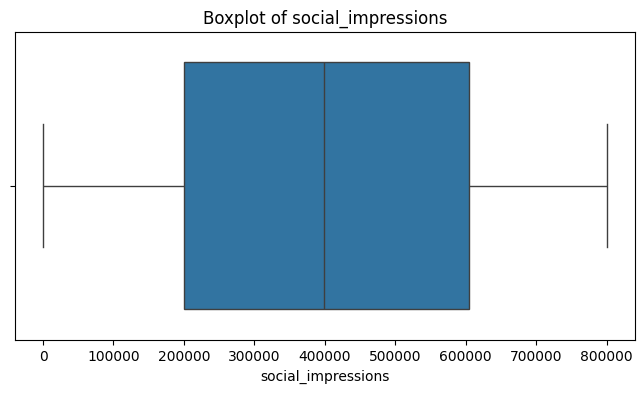

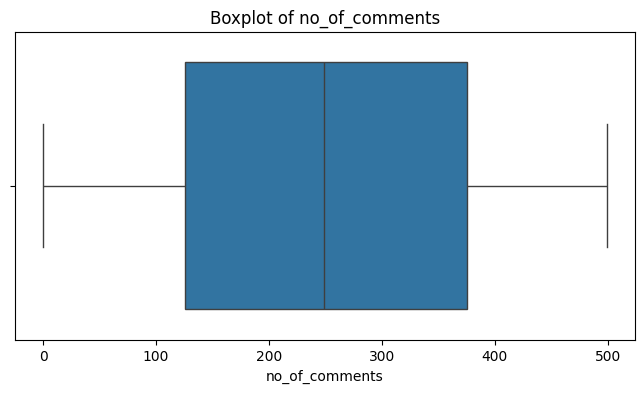

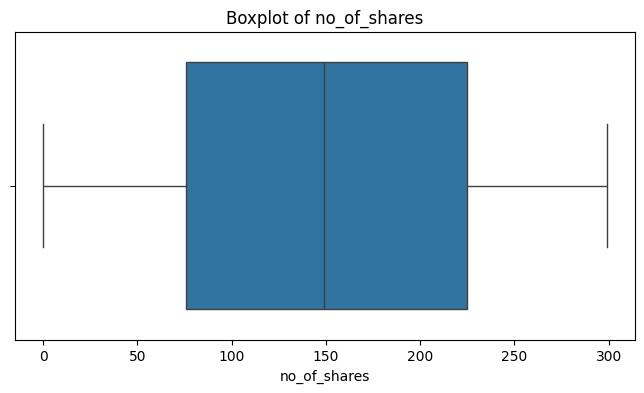

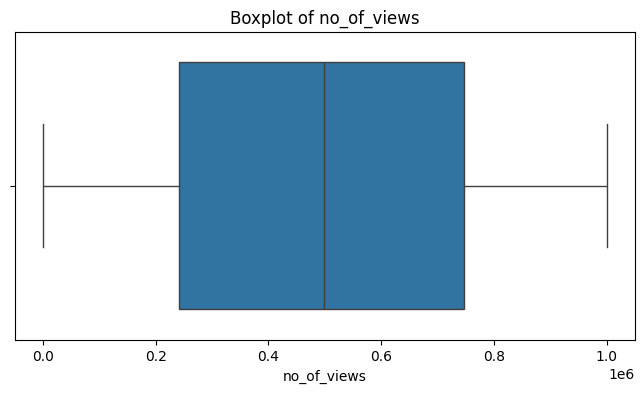

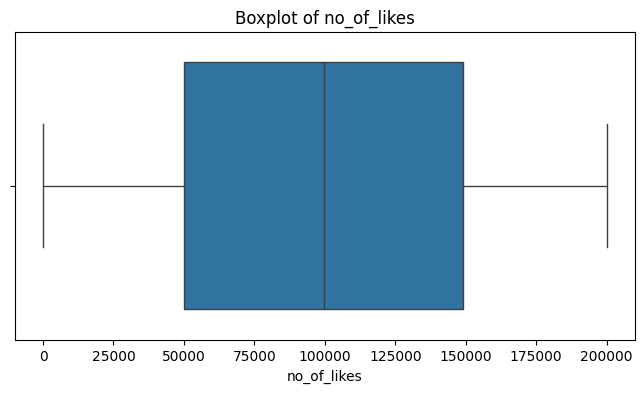

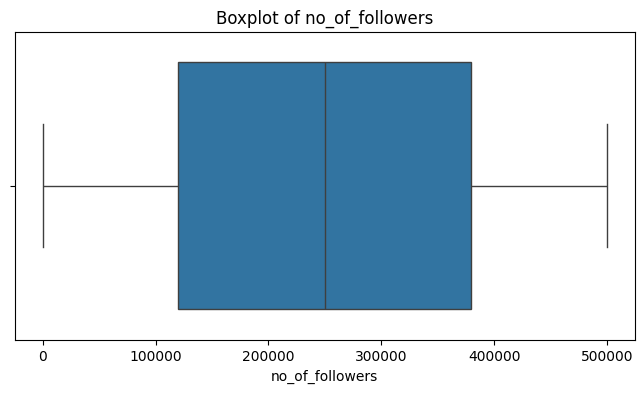

In [42]:
for col in outlier_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

we can saw there is no extreme outliers are present.

# Distribution Plots (Histogram + KDE)

In [43]:
dist_cols = [
    'social_impressions',
    'no_of_comments',
    'no_of_shares',
    'no_of_views',
    'no_of_likes',
    'no_of_followers'
]

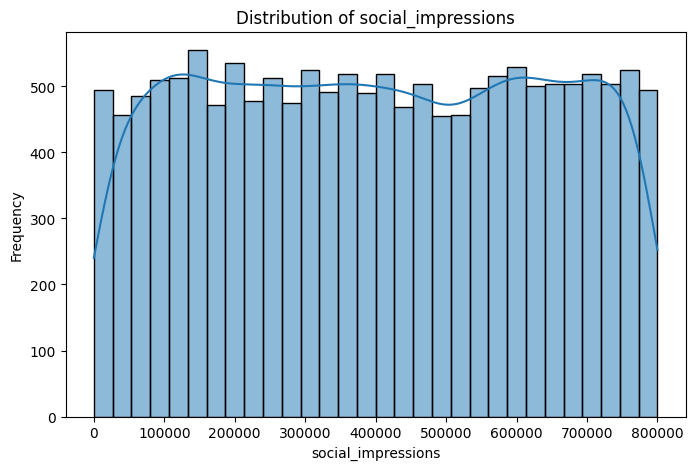

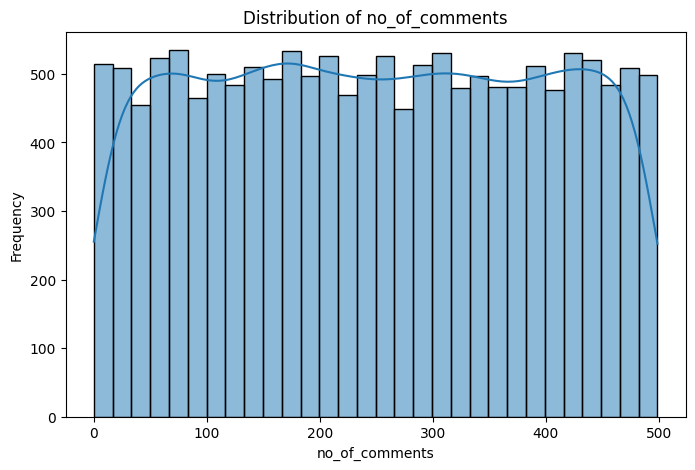

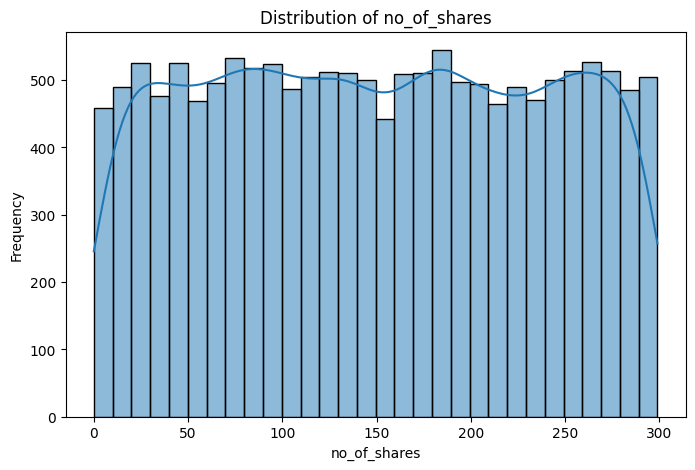

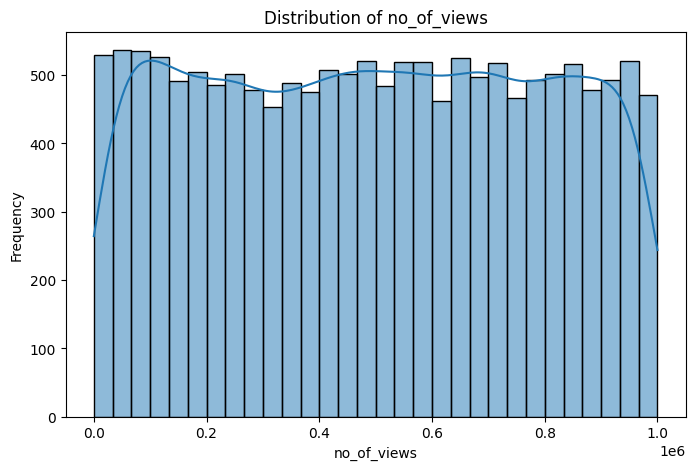

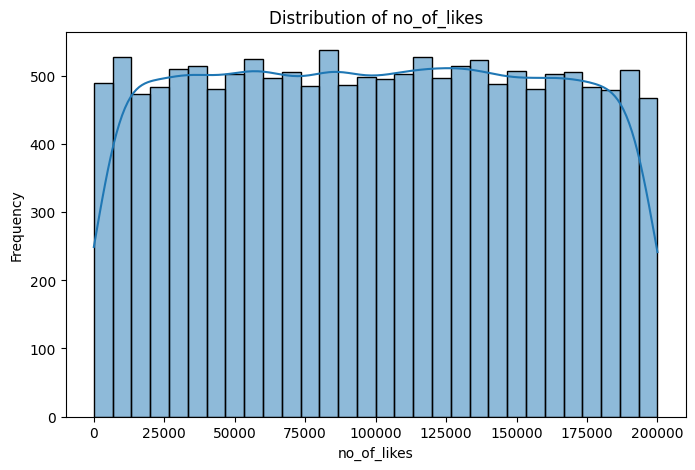

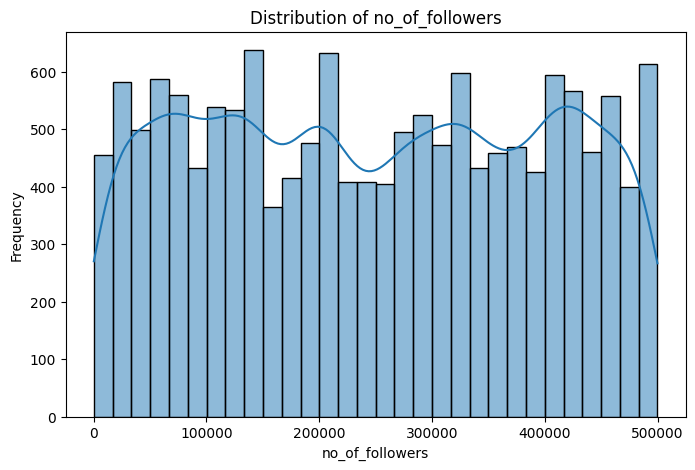

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in dist_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


# STEP 12: Correlation Analysis

In [46]:
corr_cols = [
    'social_impressions',
    'no_of_comments',
    'no_of_shares',
    'no_of_views',
    'no_of_likes',
    'no_of_followers'
]

In [47]:
corr_matrix = df[corr_cols].corr()
corr_matrix


,social_impressions,no_of_comments,no_of_shares,no_of_views,no_of_likes,no_of_followers
social_impressions,1.000000,0.017670,0.003879,0.004347,-0.007617,0.003003
no_of_comments,0.017670,1.000000,-0.011408,-0.002052,0.000448,0.006337
no_of_shares,0.003879,-0.011408,1.000000,0.000794,-0.011008,0.011072
no_of_views,0.004347,-0.002052,0.000794,1.000000,0.012106,-0.000017
no_of_likes,-0.007617,0.000448,-0.011008,0.012106,1.000000,-0.005243
no_of_followers,0.003003,0.006337,0.011072,-0.000017,-0.005243,1.000000


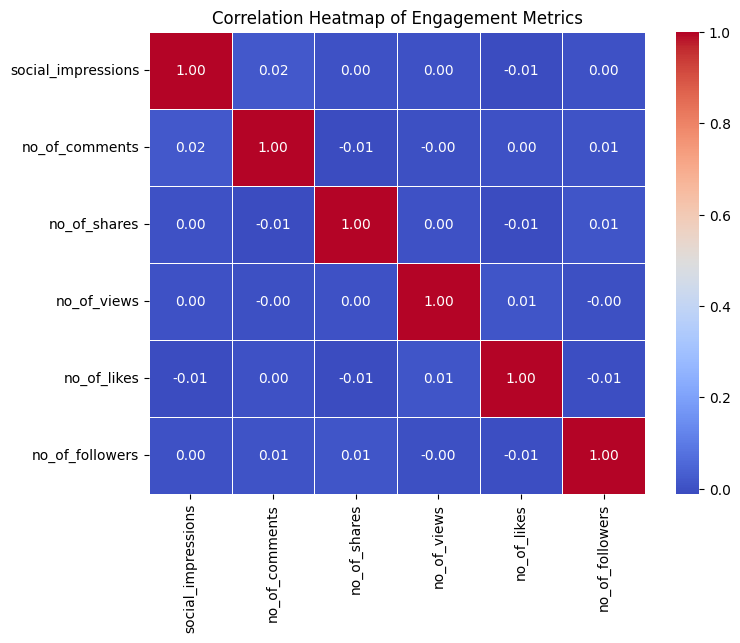

In [48]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation Heatmap of Engagement Metrics")
plt.show()


# question - 4 - Sentiment Analysis Distribution

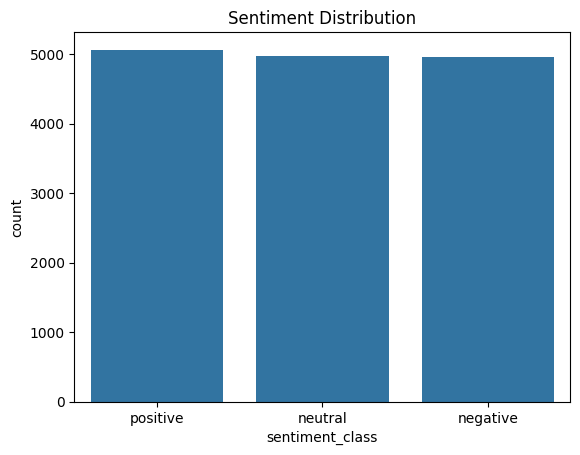

In [51]:
df['sentiment_class'].value_counts()

sns.countplot(x='sentiment_class', data=df, order=df['sentiment_class'].value_counts().index)
plt.title("Sentiment Distribution")
plt.show()

In [50]:
df.groupby('topics')['no_of_views'].mean().sort_values(ascending=False)

topics
handheld video games    503423.079017
Nintendo consoles       497310.232404
games,Nintendo games    495717.263833
                        494478.670967
Name: no_of_views, dtype: float64

In [54]:
df.columns

Index(['content_id', 'source', 'title', 'content', 'date', 'url', 'topics',
       'entities', 'sentiment_class', 'social_impressions', 'no_of_comments',
       'no_of_shares', 'no_of_views', 'no_of_likes', 'user_source_id',
       'user_name', 'user_screen_name', 'no_of_followers', 'latitude',
       'longitude', 'language'],
      dtype='object')

In [55]:
engagement_cols = ['no_of_likes', 'no_of_shares', 'no_of_views']

sentiment_engagement_mean = (
    df.groupby('sentiment_class')[engagement_cols]
    .mean()
)

sentiment_engagement_mean


,no_of_likes,no_of_shares,no_of_views
sentiment_class,,,
negative,99401.364388,150.010486,501829.538415
neutral,100311.231867,150.341169,494750.085996
positive,99375.214258,148.766390,493636.217615


In [56]:
sentiment_engagement_median = (
    df.groupby('sentiment_class')[engagement_cols]
    .median()
)

sentiment_engagement_median


,no_of_likes,no_of_shares,no_of_views
sentiment_class,,,
negative,98805.0,150.0,514309.0
neutral,101203.0,151.0,490004.0
positive,99144.5,147.0,492581.0


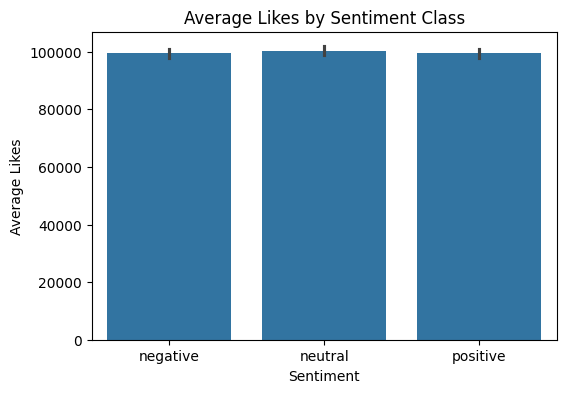

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(
    x='sentiment_class',
    y='no_of_likes',
    data=df,
    estimator='mean'
)
plt.title("Average Likes by Sentiment Class")
plt.xlabel("Sentiment")
plt.ylabel("Average Likes")
plt.show()


# Questio - 5 - Engagement and sentiment

In [60]:
# Encode sentiment
sentiment_map = {'negative': -1, 'neutral': 0, 'positive': 1}
df['sentiment_encoded'] = df['sentiment_class'].map(sentiment_map)


In [62]:
# Correlation with engagement
df[['sentiment_encoded', 'no_of_likes', 'no_of_shares', 'no_of_views']].corr()


,sentiment_encoded,no_of_likes,no_of_shares,no_of_views
sentiment_encoded,1.000000,-0.000232,-0.005912,-0.011514
no_of_likes,-0.000232,1.000000,-0.011008,0.012106
no_of_shares,-0.005912,-0.011008,1.000000,0.000794
no_of_views,-0.011514,0.012106,0.000794,1.000000


In [63]:
df.dtypes

content_id                    object
source                        object
title                         object
content                       object
date                  datetime64[ns]
url                           object
topics                        object
entities                      object
sentiment_class               object
social_impressions             int64
no_of_comments                 int64
no_of_shares                   int64
no_of_views                    int64
no_of_likes                    int64
user_source_id               float64
user_name                     object
user_screen_name              object
no_of_followers              float64
latitude                     float64
longitude                    float64
language                      object
sentiment_encoded              int64
dtype: object

# Correlation Analysis: Engagement and Sentiment

In [64]:
engagement_cols = ['social_impressions', 'no_of_likes', 'no_of_comments', 'no_of_shares', 'no_of_views']
avg_engagement_by_sentiment = df.groupby('sentiment_class')[engagement_cols].mean()
print("\nAverage Engagement by Sentiment:\n", avg_engagement_by_sentiment)


Average Engagement by Sentiment:
                  social_impressions    no_of_likes  no_of_comments  \
sentiment_class                                                      
negative              400020.161928   99401.364388      249.604154   
neutral               399633.282700  100311.231867      250.388186   
positive              403852.441943   99375.214258      248.241904   

                 no_of_shares    no_of_views  
sentiment_class                               
negative           150.010486  501829.538415  
neutral            150.341169  494750.085996  
positive           148.766390  493636.217615  


In [65]:
engagement_cols_2 = ['no_of_likes', 'no_of_shares', 'no_of_views']
sentiment_engagement_mean = (
    df.groupby('sentiment_class')[engagement_cols_2]
    .mean()
)

sentiment_engagement_mean


,no_of_likes,no_of_shares,no_of_views
sentiment_class,,,
negative,99401.364388,150.010486,501829.538415
neutral,100311.231867,150.341169,494750.085996
positive,99375.214258,148.766390,493636.217615


In [66]:
df.groupby('sentiment_class')[engagement_cols].median()


,social_impressions,no_of_likes,no_of_comments,no_of_shares,no_of_views
sentiment_class,,,,,
negative,397341.0,98805.0,248.0,150.0,514309.0
neutral,394982.0,101203.0,252.0,151.0,490004.0
positive,405847.0,99144.5,247.0,147.0,492581.0


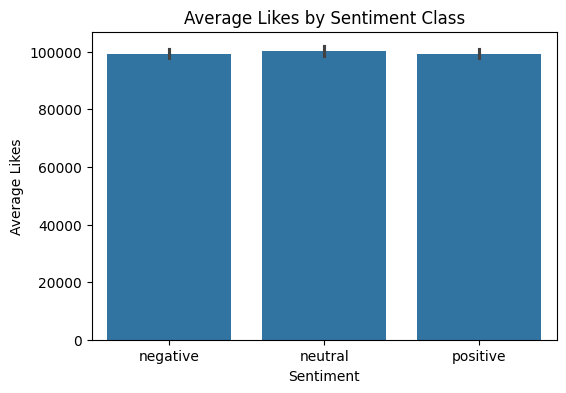

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(
    x='sentiment_class',
    y='no_of_likes',
    data=df,
    estimator='mean'
)
plt.title("Average Likes by Sentiment Class")
plt.xlabel("Sentiment")
plt.ylabel("Average Likes")
plt.show()


In [68]:
# sentiment_map = {'negative': -1, 'neutral': 0, 'positive': 1}
# df['sentiment_encoded'] = df['sentiment_class'].map(sentiment_map)

df[['sentiment_encoded', 'no_of_likes', 'no_of_shares', 'no_of_views']].corr()


,sentiment_encoded,no_of_likes,no_of_shares,no_of_views
sentiment_encoded,1.000000,-0.000232,-0.005912,-0.011514
no_of_likes,-0.000232,1.000000,-0.011008,0.012106
no_of_shares,-0.005912,-0.011008,1.000000,0.000794
no_of_views,-0.011514,0.012106,0.000794,1.000000


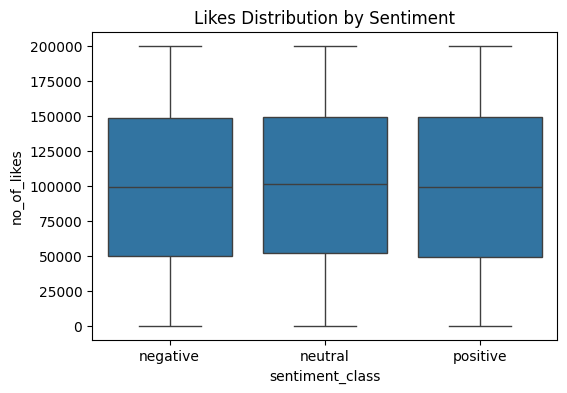

In [69]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x='sentiment_class',
    y='no_of_likes',
    data=df
)
plt.title("Likes Distribution by Sentiment")
plt.show()


# Question 6. Key Topics and Entities

Identify the most common topi s and entities mentioned in the posts.

◦ Investigate whether certain topics or entities have higher engagement



In [70]:
topic_counts = df[df['topics'] != '']['topics'].value_counts()
topic_counts.head(10)


topics
games,Nintendo games    3741
Nintendo consoles       3012
handheld video games    2278
Name: count, dtype: int64

In [71]:
entity_counts = df[df['entities'] != '']['entities'].value_counts()
entity_counts.head(10)


entities
Nintendo          5865
Nintendo, Sega    3091
Name: count, dtype: int64

In [72]:
df[df['topics'] != ''].groupby('topics')['no_of_views'].mean().sort_values(ascending=False)

topics
handheld video games    503423.079017
Nintendo consoles       497310.232404
games,Nintendo games    495717.263833
Name: no_of_views, dtype: float64

## Visualisation

In [77]:
df_topics = df[df['topics'] != '']
df_entities = df[df['entities'] != '']

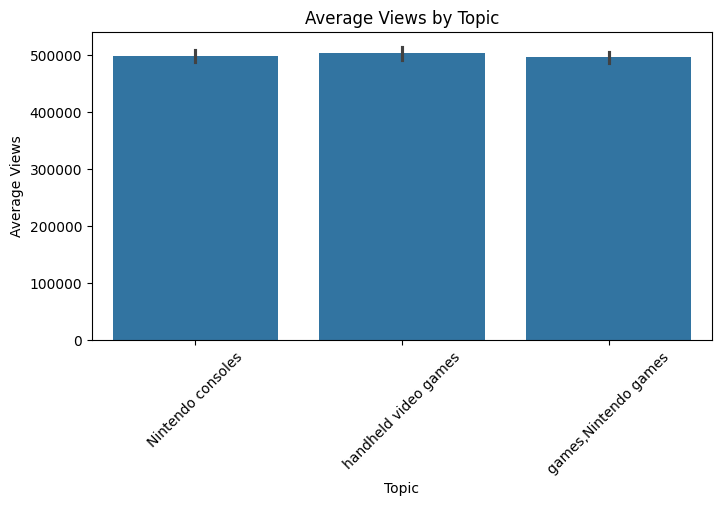

In [81]:
#Bar Plot – Average Views by Topic (MOST IMPORTANT)
# This shows which topics attract more attention.

plt.figure(figsize=(8,4))
sns.barplot(
    data=df_topics,
    x='topics',
    y='no_of_views', estimator='mean'
    
)
plt.title("Average Views by Topic")
plt.xlabel("Topic")
plt.ylabel("Average Views")
plt.xticks(rotation=45)
plt.show()


How to Interpret

Taller bar → higher average engagement

If one topic is clearly higher → topic drives engagement

If bars are similar → topic has limited effect

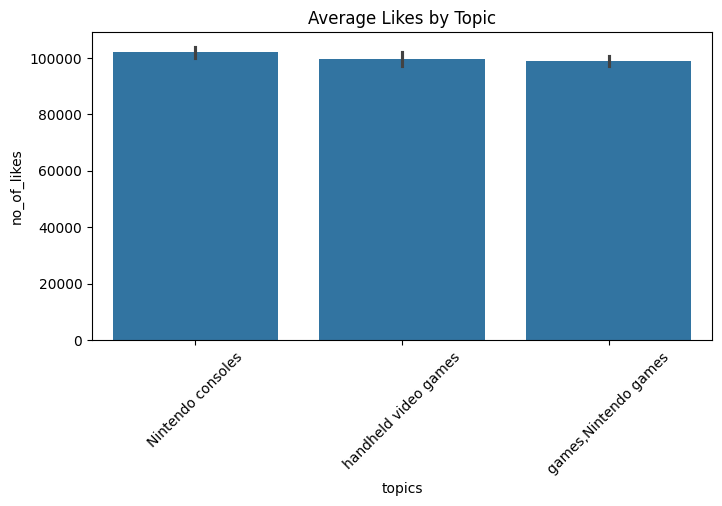

In [82]:
# Bar Plot – Average Likes by Topic
plt.figure(figsize=(8,4))
sns.barplot(
    data=df_topics,
    x='topics',
    y='no_of_likes',
    estimator='mean'
)
plt.title("Average Likes by Topic")
plt.xticks(rotation=45)
plt.show()


Interpretation

Confirms whether likes follow views

Helps validate engagement consistency

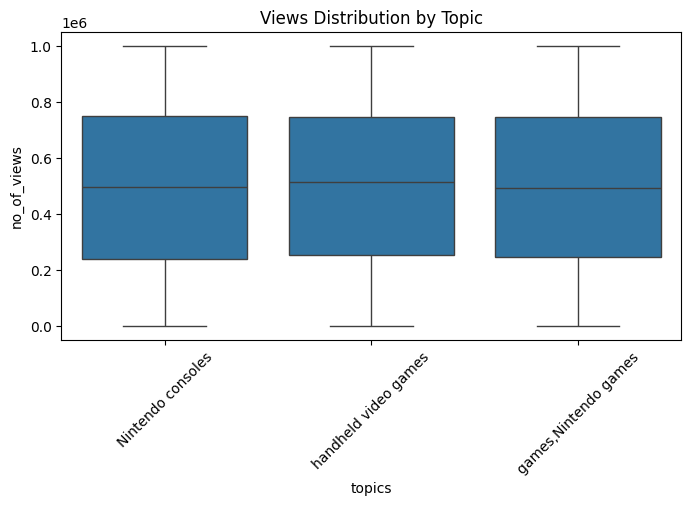

In [84]:
# Box Plot – Engagement Distribution by Topic
plt.figure(figsize=(8,4))
sns.boxplot(
    data=df_topics,
    x='topics',
    y='no_of_views'
)
plt.title("Views Distribution by Topic")
plt.xticks(rotation=45)
plt.show()


How to Interpret

Overlapping boxes → weak differentiation

One topic has higher median → stronger engagement

Wide box → inconsistent engagement

### Engagement by ENTITIES (Visual)

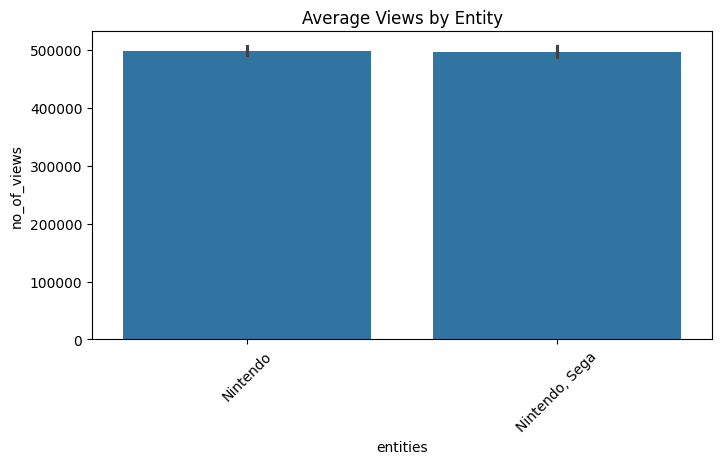

In [83]:
# Bar Plot – Average Views by Entity
plt.figure(figsize=(8,4))
sns.barplot(
    data=df_entities,
    x='entities',
    y='no_of_views',
    estimator='mean'
)
plt.title("Average Views by Entity")
plt.xticks(rotation=45)
plt.show()

“Visual analysis of engagement metrics by topic shows that certain topics consistently receive higher average views and likes compared to others. However, boxplots reveal overlapping engagement distributions, suggesting that while topic choice influences engagement, it is not the sole determining factor. A similar pattern is observed for entities, where posts mentioning specific entities attract higher engagement on average.”